# Poincare map and $\Omega_\eta$ profile (Bcrit scan)

One row per $B_{\mathrm{crit}}$ (6.5, 6.6, 6.7, 6.8). Left: perturbed Poincare from `poinc_pert_*.npz`. Right: unperturbed $\Omega_\eta(s)$ from `freq_unpert_*.npz`. Shared $s$ axis ($0$ to $1$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

data_dir = Path('.')
Bcrits = [6.5, 6.6, 6.7, 6.8]

data = {}
for Bcrit in Bcrits:
    poinc_path = data_dir / f'poinc_pert_{Bcrit}.npz'
    freq_path = data_dir / f'freq_unpert_{Bcrit}.npz'
    if not poinc_path.exists() or not freq_path.exists():
        missing = [p.name for p in (poinc_path, freq_path) if not p.exists()]
        print(f'Bcrit={Bcrit}: missing {missing}, skipping')
        continue
    poinc = np.load(poinc_path, allow_pickle=True)
    freq = np.load(freq_path)
    data[Bcrit] = {
        'etas_all': poinc['etas_all'],
        's_all': poinc['s_all'],
        'Omega_eta': freq['Omega_eta'],
        's': freq['s'],
    }
    print(
        f'Bcrit={Bcrit}: {len(poinc["etas_all"])} trajectories, '
        f'{len(freq["s"])} frequency points'
    )

list(data.keys())

Bcrit=6.5: 769 trajectories, 120 frequency points
Bcrit=6.6: 758 trajectories, 120 frequency points
Bcrit=6.7: 753 trajectories, 120 frequency points
Bcrit=6.8: 750 trajectories, 120 frequency points


[6.5, 6.6, 6.7, 6.8]

In [2]:
FontSize = 22
label_kw = {"fontfamily": "Times New Roman", "fontsize": FontSize}
tick_labelsize = FontSize - 2

plt.rcParams.update(
    {
        "font.family": "Times New Roman",
        "mathtext.fontset": "custom",
        "mathtext.rm": "Times New Roman",
        "mathtext.it": "Times New Roman:italic",
        "mathtext.bf": "Times New Roman:bold",
        "figure.figsize": (6.4, 4.8)
    }
)


# Default axes box in figure coordinates (0–1); tune once, reuse everywhere
AXES_MARGINS = dict(left=0.07, right=0.98, bottom=0.16, top=0.96) # percentages of the figure height/width

plt.rcParams.update(
    {
        "figure.subplot.left": AXES_MARGINS["left"],
        "figure.subplot.right": AXES_MARGINS["right"],
        "figure.subplot.bottom": AXES_MARGINS["bottom"],
        "figure.subplot.top": AXES_MARGINS["top"],
        # optional: spacing for multi-panel figures
        "figure.subplot.wspace": 0.25,
        "figure.subplot.hspace": 0.25,
    }
)


# apply to figures to apply even if using tight_layout
def apply_standard_axes(fig):
    fig.subplots_adjust(**AXES_MARGINS)



/var/folders/1s/jh18wdb5059c0177d80bb_xc0000gn/T/ipykernel_13595/445632207.py:15: RuntimeWarning: invalid value encountered in scalar power
  d['s_all'][i]**0.5,
/var/folders/1s/jh18wdb5059c0177d80bb_xc0000gn/T/ipykernel_13595/445632207.py:15: RuntimeWarning: invalid value encountered in power
  d['s_all'][i]**0.5,


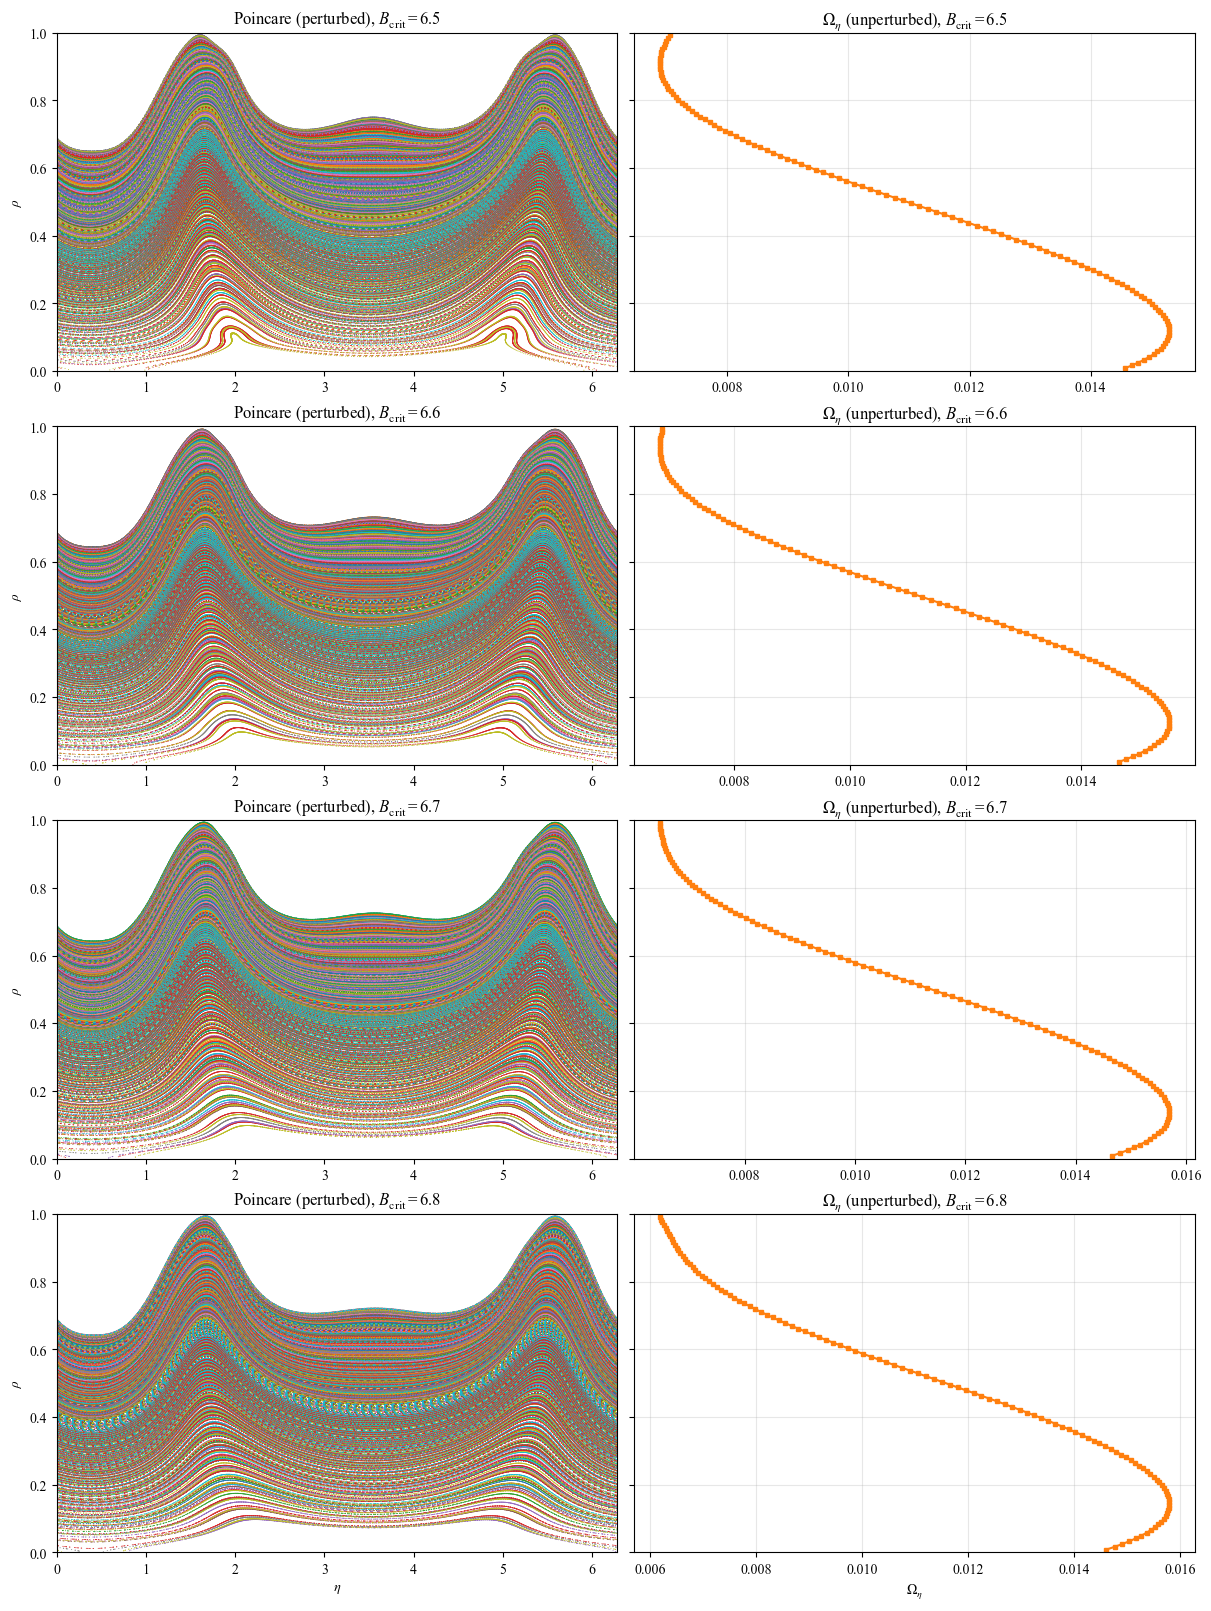

In [3]:
nrows = len(data)
fig, axes = plt.subplots(
    nrows, 2, figsize=(12, 4 * nrows), sharey=True, constrained_layout=True
)
if nrows == 1:
    axes = np.array([axes])

for row, Bcrit in enumerate(data):
    d = data[Bcrit]
    ax_poinc, ax_freq = axes[row]

    for i in range(len(d['etas_all'])):
        ax_poinc.scatter(
            np.mod(d['etas_all'][i], 2 * np.pi),
            d['s_all'][i]**0.5,
            marker='o',
            s=0.5,
            edgecolors='none',
        )
    ax_poinc.set_ylabel(r'$\rho$')
    ax_poinc.set_xlim([0, 2 * np.pi])
    ax_poinc.set_ylim([0, 1])
    ax_poinc.set_title(rf'Poincare (perturbed), $B_{{\mathrm{{crit}}}}={Bcrit}$')

    ax_freq.plot(
        -d['Omega_eta'],
        d['s'],
        color='tab:orange',
        marker='s',
        markersize=3,
        linestyle='-',
    )
    ax_freq.set_ylim([0, 1])
    ax_freq.set_title(rf'$\Omega_{{\eta}}$ (unperturbed), $B_{{\mathrm{{crit}}}}={Bcrit}$')
    ax_freq.grid(True, alpha=0.3)

axes[-1, 0].set_xlabel(r'$\eta$')
axes[-1, 1].set_xlabel(r'$\Omega_{\eta}$')
plt.show()

/var/folders/1s/jh18wdb5059c0177d80bb_xc0000gn/T/ipykernel_13595/2842855436.py:28: RuntimeWarning: invalid value encountered in sqrt
  buckets_rho[k].append(np.asarray(s_all[i], float) ** 0.5)


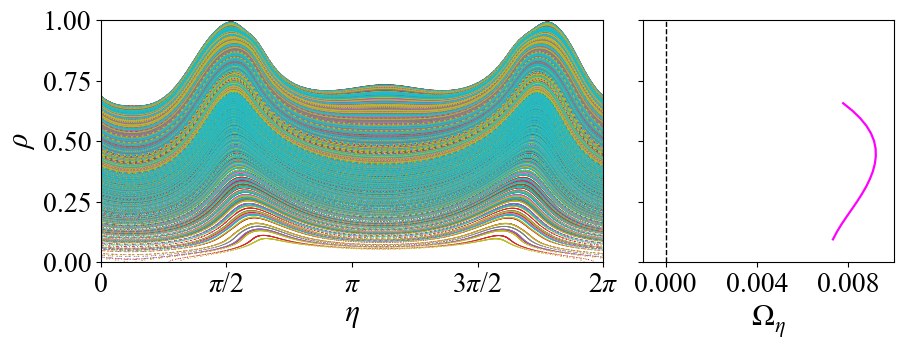

In [4]:
import matplotlib

FontSize = 22
label_kw = {"fontfamily": "Times New Roman", "fontsize": FontSize}
tick_labelsize = FontSize - 2

Bcrit = 6.6
poinc = np.load(data_dir / f'poinc_pert_{Bcrit}.npz', allow_pickle=True)
desc = np.load(data_dir / f'desc_omega_eta_Bcrit{Bcrit}.npz')

etas_all = poinc['etas_all']
s_all = poinc['s_all']
n_traj = len(etas_all)

fig, (axL, axR) = plt.subplots(
    1, 2, figsize=(9.0, 3.6), gridspec_kw={"width_ratios": [2, 1]},
)

# Same colors as a per-trajectory scatter loop (matplotlib prop cycle), but
# one scatter call per cycle color for speed.
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
n_colors = len(colors)
buckets_eta = [[] for _ in range(n_colors)]
buckets_rho = [[] for _ in range(n_colors)]
for i in range(n_traj):
    k = i % n_colors
    buckets_eta[k].append(np.mod(np.asarray(etas_all[i], float), 2 * np.pi))
    buckets_rho[k].append(np.asarray(s_all[i], float) ** 0.5)
for k in range(n_colors):
    if not buckets_eta[k]:
        continue
    axL.scatter(
        np.concatenate(buckets_eta[k]),
        np.concatenate(buckets_rho[k]),
        marker="o", s=0.5, c=colors[k], edgecolors="none", rasterized=True,
    )

axL.set_xlim(0, 2 * np.pi)
axL.set_ylim(0, 1)
axL.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
axL.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
axL.set_xlabel(r"$\eta$", **label_kw)
axL.set_ylabel(r"$\rho$", **label_kw)
axL.tick_params("both", labelsize=tick_labelsize)

# Restrict DESC Omega_eta to s covered by eta=0 Poincare launch points
s0 = np.array([float(np.asarray(s_all[i])[0]) for i in range(n_traj)])
e0 = np.array([float(np.mod(np.asarray(etas_all[i])[0], 2 * np.pi)) for i in range(n_traj)])
s_eta0 = s0[e0 < 1e-8]
s_desc = desc['s_6.600']
Om_desc = desc['Omega_6.600']
in_range = (s_desc >= s_eta0.min()) & (s_desc <= s_eta0.max())

axR.plot(
    Om_desc[in_range],
    s_desc[in_range]**0.5,
    "-", color="magenta", lw=1.6, label="DESC",
)
axR.axvline(0, color="k", ls="--", lw=1.0)
axR.set_ylim(0, 1)
axR.set_yticklabels([])
axR.set_xlabel(r"$\Omega_\eta$", **label_kw)
axR.set_xlim(-0.001, 0.010)
axR.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(3))
axR.tick_params("both", labelsize=tick_labelsize)

fig.tight_layout()
plt.show()


/var/folders/1s/jh18wdb5059c0177d80bb_xc0000gn/T/ipykernel_13595/322801096.py:27: RuntimeWarning: invalid value encountered in sqrt
  e[:m], s[:m] ** 0.5,


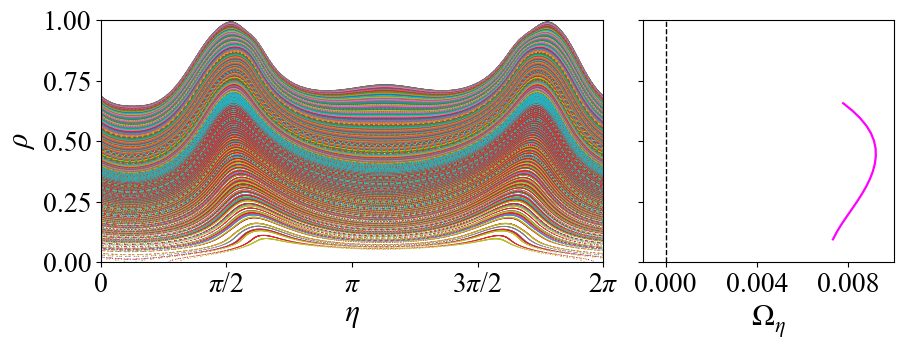

In [5]:
import matplotlib

FontSize = 22
label_kw = {"fontfamily": "Times New Roman", "fontsize": FontSize}
tick_labelsize = FontSize - 2

Bcrit = 6.6
stride = 1  # plot every stride-th trajectory (1 = all)

poinc = np.load(data_dir / f'poinc_pert_{Bcrit}.npz', allow_pickle=True)
desc = np.load(data_dir / f'desc_omega_eta_Bcrit{Bcrit}.npz')

etas_all = poinc['etas_all']
s_all = poinc['s_all']
n_traj = len(etas_all)
traj_idx = range(0, n_traj, stride)

fig, (axL, axR) = plt.subplots(
    1, 2, figsize=(9.0, 3.6), gridspec_kw={"width_ratios": [2, 1]},
)

for i in traj_idx:
    s = np.asarray(s_all[i], float)
    e = np.mod(np.asarray(etas_all[i], float), 2 * np.pi)
    m = min(s.size, e.size)
    axL.scatter(
        e[:m], s[:m] ** 0.5,
        marker="o", s=0.5, edgecolors="none", rasterized=True,
    )

axL.set_xlim(0, 2 * np.pi)
axL.set_ylim(0, 1)
axL.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
axL.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
axL.set_xlabel(r"$\eta$", **label_kw)
axL.set_ylabel(r"$\rho$", **label_kw)
axL.tick_params("both", labelsize=tick_labelsize)

# Restrict DESC Omega_eta to s covered by eta=0 Poincare launch points that are plotted
s0 = np.array([float(np.asarray(s_all[i])[0]) for i in traj_idx])
e0 = np.array([float(np.mod(np.asarray(etas_all[i])[0], 2 * np.pi)) for i in traj_idx])
s_eta0 = s0[e0 < 1e-8]
s_desc = desc['s_6.600']
Om_desc = desc['Omega_6.600']
in_range = (s_desc >= s_eta0.min()) & (s_desc <= s_eta0.max())

axR.plot(
    Om_desc[in_range],
    s_desc[in_range]**0.5,
    "-", color="magenta", lw=1.6, label="DESC",
)
axR.axvline(0, color="k", ls="--", lw=1.0)
axR.set_ylim(0, 1)
axR.set_yticklabels([])
axR.set_xlabel(r"$\Omega_\eta$", **label_kw)
axR.set_xlim(-0.001, 0.010)
axR.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(3))
axR.tick_params("both", labelsize=tick_labelsize)

fig.tight_layout()
# plt.show()
fig.savefig('poincare_rho_and_omega_eta_Bcrit_6.600.pdf')
